# Monte Carlo Markov Chain (MCMC)


A **Markov Chain** is a `random walk` that maintains the **memoryless property**. In other words, each step, or probability, in the system is independent of the previous.


In probability theory and statistics, a Markov chain or Markov process is a stochastic process describing a sequence of possible events in which the probability of each event depends only on the state attained in the previous event. Informally, this may be thought of as, "What happens next depends only on the state of affairs now

<img src="https://upload.wikimedia.org/wikipedia/commons/2/2b/Markovkate_01.svg" width="300">

## Random numbers (pseudo random)

Before moving in details, let's consider some kinds of randon numbers generators:

In [1]:
import numpy as np
import random
import math
import matplotlib.pyplot as plt

In [2]:
#Función randint: genera un número aleatorio entero entre 0 y n, siendo el segundo valor 30 en este caso.

print('randint =',random.randint(0, 10))

#Función uniform: nos permite generar valores aleatorios que sean decimales podemos hacer uso de uniform.
print('uniform =',random.uniform(0, 10))

#Función random: random que no acepta parámetros y genera números aleatorios decimales de entre 0 y 1.
print('random =',random.random())

#Función choice:nos permite elegir un elemento aleatorio de una lista.
fruits = ['11', '22', '33']
print('choice =',random.choice(fruits))



randint = 2
uniform = 5.704275446551128
random = 0.044328898888103985
choice = 11


## The Drunkard’s Walk ... the random walk

Let's consider a drunk wall where in each step the drunk man maintains the same probability of moving forwards or backwards whether he’s on the cliff’s edge or many steps away from it.

**1D Random Walk**
This example simulates a one-dimensional random walk where a walker starts at a fixed point and moves left or right randomly at each step. The path of the walker is plotted using matplotlib.
https://www.geeksforgeeks.org/python/random-walk-implementation-python/

In [4]:
import numpy as np
import random
import math
import matplotlib.pyplot as plt

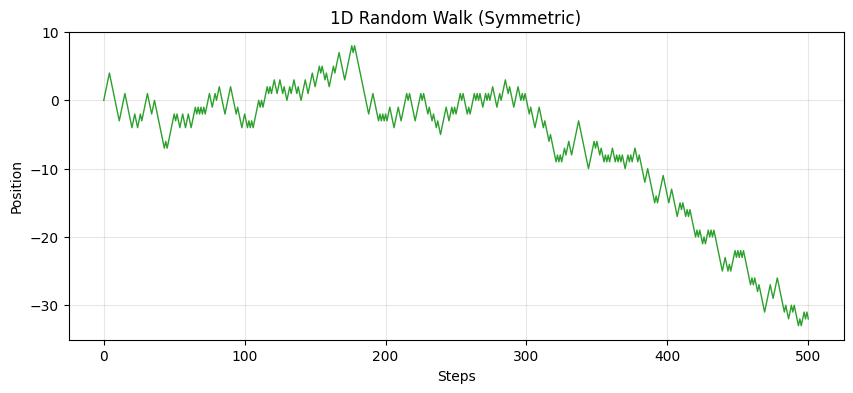

In [17]:
steps = 500
origin = 0

step_set = np.array([-1, 1]) # two posible values
random_steps = np.random.choice(step_set, size=steps) # choice between -1 o +1

path = np.concatenate([[origin], np.cumsum(random_steps)]) # np.cumsum suma las numeros del array sucesivamente

plt.figure(figsize=(10, 4))
plt.plot(path, color='#2ca02c', linewidth=1)
plt.title("1D Random Walk (Symmetric)")
plt.xlabel("Steps")
plt.ylabel("Position")
plt.grid(True, alpha=0.3)
plt.show()

Explanation:

* origin = 0 walker starts at position 0.
* step_set = np.array([-1, 1]) each step can be -1 (left) or +1 (right).
* np.random.choice(step_set, size=steps) randomly select steps for the walk.
* np.cumsum(random_steps) compute cumulative sum to get walker’s position at each step.

**2D Random Walk in Python**
A 2D random walk lets the walker move in four directions up, down, left or right creating more complex paths compared to 1D. The final path is plotted to visualize the movement on a 2D plane.

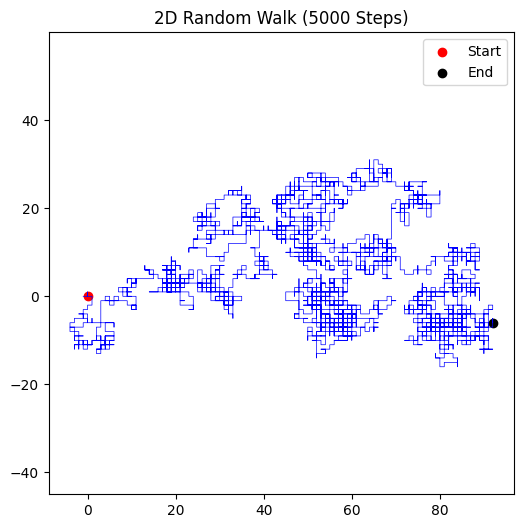

In [18]:
#import numpy as np
#import matplotlib.pyplot as plt

n = 5000
moves = np.array([(0, 1), (0, -1), (1, 0), (-1, 0)])

random_indices = np.random.choice(len(moves), size=n)
steps = moves[random_indices]

coords = np.cumsum(steps, axis=0)
x, y = coords[:, 0], coords[:, 1]

plt.figure(figsize=(6, 6))
plt.plot(x, y, lw=0.5, color='blue')
plt.scatter(0, 0, color='red', label='Start')
plt.scatter(x[-1], y[-1], color='black', label='End')
plt.title(f"2D Random Walk ({n} Steps)")
plt.legend()
plt.axis('equal')
plt.show()

**Explanation:**

* moves = np.array([(0,1),(0,-1),(1,0),(-1,0)]) define possible moves: up, down, right, left.
* np.random.choice(len(moves), size=n) randomly select n moves.
* steps = moves[random_indices] create sequence of steps for the walk.
* np.cumsum(steps, axis=0) compute cumulative (x, y) positions for the walker.
* plt.plot(x, y) plot the 2D path; plt.scatter marks start (red) and end (black).
* plt.axis('equal') ensures x and y axes have the same scale for accurate visualization.

## The Drunkard’s Walk distribution

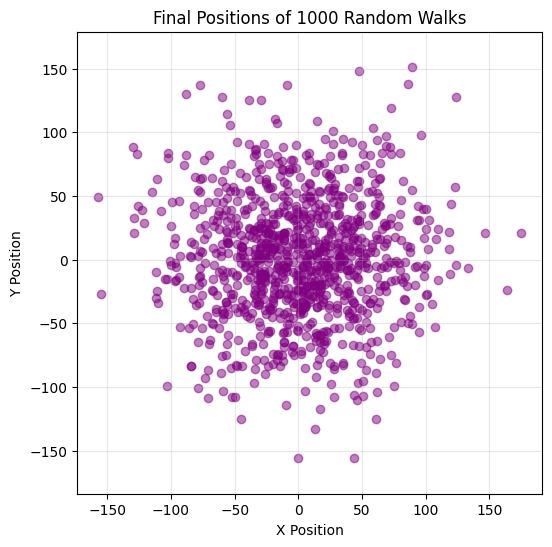

In [11]:
## Mostremos el resultado de 1000 caminatas aleatorias en 2D, cada una con 5000 pasos, 
# para observar la distribución de las posiciones finales.

n_walks = 1000
final_positions = np.zeros((n_walks, 2))
for i in range(n_walks):
    random_indices = np.random.choice(len(moves), size=n)
    steps = moves[random_indices]
    coords = np.cumsum(steps, axis=0)
    final_positions[i] = coords[-1] # Guardamos la posición final de cada caminata
plt.figure(figsize=(6, 6))
plt.scatter(final_positions[:, 0], final_positions[:, 1], alpha=0.5, color='purple')
plt.title(f"Final Positions of {n_walks} Random Walks")
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

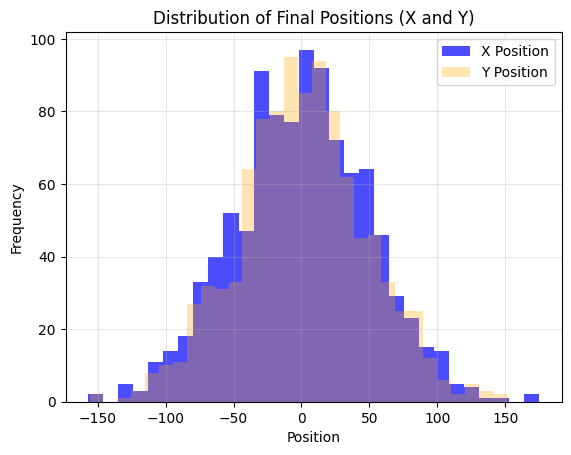

In [12]:
plt.hist(final_positions[:, 0], bins=30, alpha=0.7, color='blue', label='X Position')
plt.hist(final_positions[:, 1], bins=30, alpha=0.3, color='orange', label='Y Position')
plt.title(f"Distribution of Final Positions (X and Y)")
plt.xlabel("Position")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

We see that the distribution is center in (0,0).

## Metropolis-Hastings method

Uno de los métodos MCMC más populares es el algoritmo Metropolis-Hastings; de hecho la mayoría de los algoritmos de MCMC pueden ser interpretados como casos especiales de este algoritmo. 

El algoritmo Metropolis-Hastings está catalogado como uno de los 10 algoritmos más importantes y más utilizados en ciencia e ingeniería en los últimos veinte años. Se encuentra en el corazón de la mayoría de los métodos de muestreo MCMC. El problema básico que intenta resolver el algoritmo Metropolis-Hastings es proporcionar un método para generar muestras de alguna distribución genérica $P(x)$.

La idea es que en muchos casos, podemos saber cómo escribir la ecuación para la distribución de probabilidad $P(x)$, pero no sabemos cómo generar muestras aleatorias de la misma. Entonces la idea básica detrás de este algoritmo es la de construir una cadena de Markov cuya distribución invariante sea la distribución de muestreo que deseamos, es decir $P(x)$. En principio, esto puede parecer bastante complicado, pero la flexibilidad inherente en la elección de las probabilidades de transición lo hacen más simple de lo que parece.

IA-wiki:

**¿Cómo funciona el Método?**

El algoritmo crea una "cadena", donde cada nuevo estado o muestra depende únicamente del estado anterior. El proceso se repite miles de veces siguiendo estos pasos:

1. Estado inicial: Se elige un punto de partida \(x\) arbitrario para el parámetro que deseas estudiar.
2. Generar una propuesta: Se propone un nuevo salto a un estado vecino \(x'\) utilizando una distribución de probabilidad simétrica (por ejemplo, una distribución normal) centrada en el estado actual \(x\).
3. Calcular la probabilidad de aceptación \(A\): Se compara la probabilidad del nuevo estado propuesto frente a la del estado actual. Esta regla de decisión se calcula matemáticamente así: $A=\text{min}\left(1,\dfrac{P(x')}{P(x)}\right)$
4. Tomar la decisión:
* Si la probabilidad del nuevo estado es mayor $(P(x') \geq P(x)$, el salto siempre se acepta $A \geq 1$.
* Si es menor, el salto se puede aceptar o rechazar de forma probabilística. Para ello, el algoritmo genera un número aleatorio entre $[0,1]$ y, si este número es menor que \(A\), se acepta la propuesta. En caso contrario, te quedas en el estado actual.5. 
* Iteración: El punto aceptado (o rechazado) se convierte en el nuevo punto de partida y el proceso se repite desde el paso 2.

Tras muchas iteraciones, el conjunto de puntos aceptados convergerá hacia la distribución de probabilidad real, permitiendo aproximar comportamientos muy complejos en campos como la física estadística, la inferencia bayesiana y la computación gráfica

¿cómo funciona? ver:
https://relopezbriega.github.io/blog/2017/01/10/introduccion-a-los-metodos-de-monte-carlo-con-python/

In [14]:
from scipy.stats import norm
from scipy.stats import beta
import numpy as np
import matplotlib.pyplot as plt

**Normal and beta distribution**

$p(x;\mu,\sigma^2)=\dfrac{1}{\sigma \sqrt{2\pi}} e^{-\dfrac{1}{2}\left(\dfrac{x-μ}{\sigma}\right)^2}$

$f(x;\alpha,\beta)=\dfrac{x^{(\alpha-1) (1-x)^{\beta-1}}}{B(\alpha,\beta)}$ in $[0,1]$ with $B(\alpha,\beta)=\dfrac{\Gamma(\alpha)\Gamma(\beta)}{\Gamma(\alpha+\beta)}$

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html

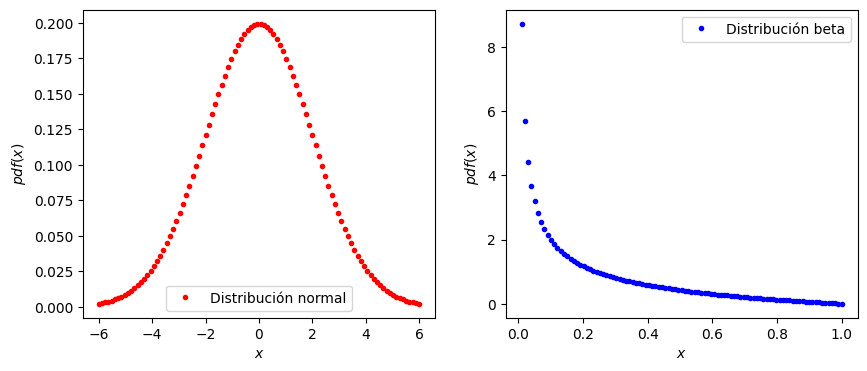

In [16]:
x = np.linspace(-6, 6, 100)
x2 = np.linspace(0, 1, 100)
y = norm(0, 2).pdf(x) #mu=mean es 1 y sigma es 2
y2 = beta(0.4, 2).pdf(x2) #mu=mean es 1 y sigma es 2
#figure
plt.figure(figsize=(10,4))

plt.subplot(1, 2, 1)
plt.plot(x, y, 'r.', lw=3, label='Distribución normal')
plt.xlabel('$x$', fontsize=10)
plt.ylabel('$pdf(x)$', fontsize=10)
plt.legend(fontsize=10)

plt.subplot(1, 2, 2)
plt.plot(x2, y2, 'b.', lw=3, label='Distribución beta')
plt.xlabel('$x$', fontsize=10)
plt.ylabel('$pdf(x)$', fontsize=10)
plt.legend(fontsize=10)
plt.show()

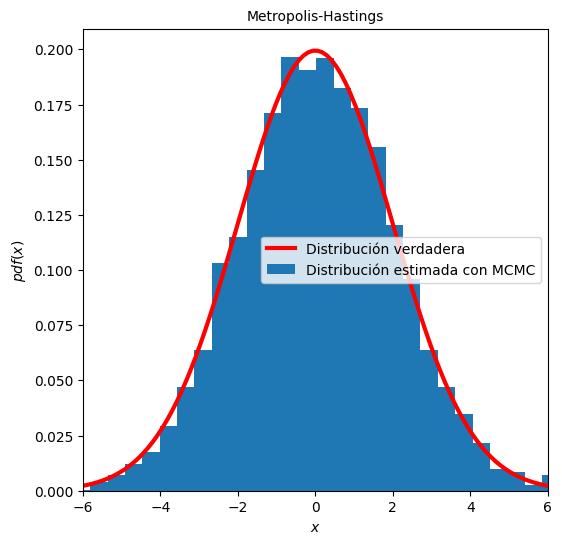

In [19]:
from scipy.stats import norm
#****************************************
#     Algorith: Metropolis-Hasting
#****************************************
def metropolis(func, steps=10000):
    """A very simple Metropolis implementation"""
    muestras = np.zeros(steps)
    old_x = func.mean() # 0
    old_prob = func.pdf(old_x)

    for i in range(steps):
        new_x = old_x + np.random.normal(0, 0.5)
        new_prob = func.pdf(new_x)
        aceptacion = new_prob / old_prob
        if aceptacion >= np.random.random():
            muestras[i] = new_x
            old_x = new_x
            old_prob = new_prob
        else:
            muestras[i] = old_x

    return muestras

# Normal distribution
func = norm(0, 2)
samples = metropolis(func=func)#read the normal distribution
x = np.linspace(-6, 6, 100)
y = func.pdf(x)
plt.figure(figsize=(6,6))
plt.xlim(-6, 6)
plt.plot(x, y, 'r-', lw=3, label='Distribución verdadera')
plt.hist(samples, bins=30, density=True, label='Distribución estimada con MCMC')
plt.xlabel('$x$', fontsize=10)
plt.ylabel('$pdf(x)$', fontsize=10)
plt.title('Metropolis-Hastings', fontsize=10)
plt.legend(fontsize=10,loc='best')
plt.show()

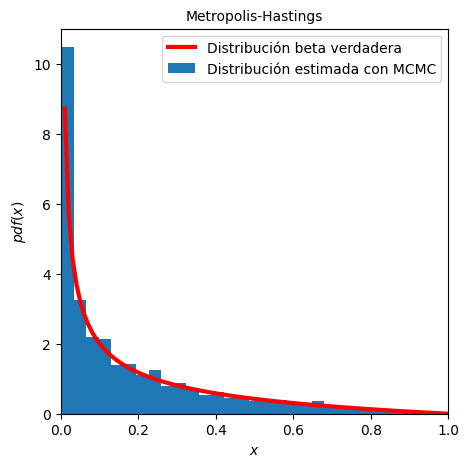

In [20]:
#*******************
# Beta distribution
#******************
from scipy.stats import beta
func = beta(0.4, 2)

samples = metropolis(func=func)
x = np.linspace(0, 1, 100)
y = func.pdf(x)

plt.figure(figsize=(5,5))
plt.xlim(0, 1)
plt.plot(x, y, 'r-', lw=3, label='Distribución beta verdadera')
plt.hist(samples, bins=30, density=True, label='Distribución estimada con MCMC')
plt.xlabel('$x$', fontsize=10)
plt.ylabel('$pdf(x)$', fontsize=10)
plt.title('Metropolis-Hastings', fontsize=10)
plt.legend(fontsize=10,loc='best')
plt.show()

## Exercise: Ising model 1D and 2D

<img src="https://upload.wikimedia.org/wikipedia/commons/f/fe/2D_ising_model_on_lattice.svg" width="600">
